In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [21]:
df=pd.read_csv("D:\\jn\\qskill-python-aiml-internship\\Task_2_python_Dataanalysis\\data\\train.csv")
df.head(5)
df.shape
df.dtypes

lot_median=df['LotFrontage'].median()
df['LotFrontage']=df['LotFrontage'].fillna(lot_median)
df=df.drop( 'Id',axis=1)
df.isnull().sum()

MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
Street           0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 80, dtype: int64

In [ ]:
# Define target variable
y=df['SalePrice']

# Define feature variables (all columns except SalePrice)
X=df.drop('SalePrice',axis=1)
print(X.shape)
print(y.shape)

(1460, 79)
(1460,)


In [25]:
#One Hot encoding
# Identify categorical columns
Categorical_columns=X.select_dtypes(include=['object']).columns

# Apply One-Hot Encoding
X=pd.get_dummies(X,columns=Categorical_columns,drop_first=True)
X.select_dtypes(include=['object']).sum()

Series([], dtype: float64)

In [42]:
X = X.fillna(0)
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)







(1168, 244)
(292, 244)


In [43]:
#Initialize Linear Regression
from sklearn.linear_model import LinearRegression
model=LinearRegression()

#Train (Fit) the Model
model.fit(X_train,y_train)

#Make Predictions
y_pred=model.predict(X_test)


In [44]:
#Evaluation Code
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("MAE:",mae)
print("MSE:",mse)
print("R2 score:",r2)
    



MAE: 20493.833660723656
MSE: 2438780306.60641
R2 score: 0.682049988392767


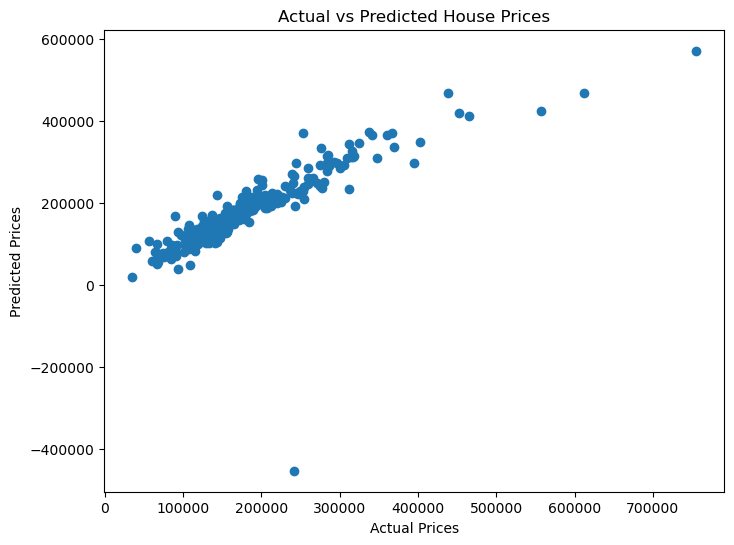

In [ ]:
#Graphical representation
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

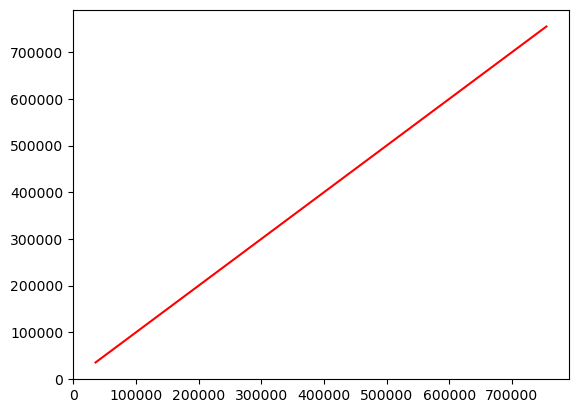

In [ ]:
#Diagnol reference line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

Model Evaluation

The performance of the Linear Regression model was evaluated using MAE, MSE, and R² score.

MAE: 20,493
On average, the model’s predictions differ from the actual house prices by about $20,493.

MSE: 243,878,306
This metric penalizes larger errors more heavily due to squaring.

R² Score: 0.68
The model explains approximately 68% of the variation in house prices.

Conclusion

The Linear Regression model performs reasonably well and captures the overall trend in house prices.
Although not perfect, it provides a solid baseline model for predicting housing prices